# Feature Engineering — Detección de fraude

**Objetivo:** Construir features nuevas a partir del dataset limpio, documentando la justificación de cada una.

**Input:** `data/processed/creditcard_clean.csv`
**Output:** `data/processed/creditcard_features.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
df = pd.read_csv('data/processed/creditcard_clean.csv')
print('Shape:', df.shape)
df.head()

Shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Sección 1 — Feature temporal (Time)

Se crea `hour` (hora del día) porque el EDA mostró concentración de fraude en ciertas ventanas temporales. Capturar el ciclo diario puede ser más informativo que el timestamp crudo.

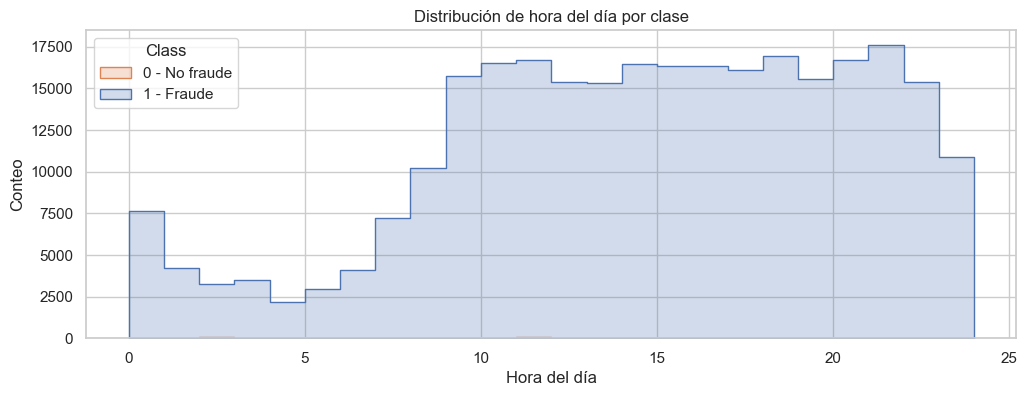

count    283726.000000
mean         14.537139
std           5.846094
min           0.000000
25%          10.597500
50%          15.008889
75%          19.329167
max          23.999444
Name: hour, dtype: float64


In [3]:
df['hour'] = (df['Time'] / 3600) % 24
plt.figure(figsize=(12, 4))
sns.histplot(data=df, x='hour', hue='Class', bins=24, element='step')
plt.title('Distribución de hora del día por clase')
plt.xlabel('Hora del día')
plt.ylabel('Conteo')
plt.legend(title='Class', labels=['0 - No fraude', '1 - Fraude'])
plt.show()
print(df['hour'].describe())

**Interpretación:** El fraude se concentra en determinadas horas del día, lo que confirma que `hour` aporta señal temporal relevante.

## Sección 2 — Feature de monto (Amount)

`Amount` tiene distribución muy asimétrica (cola larga, outliers). Se crea `log_amount = log1p(Amount)` para comprimir la escala y reducir el impacto de outliers.

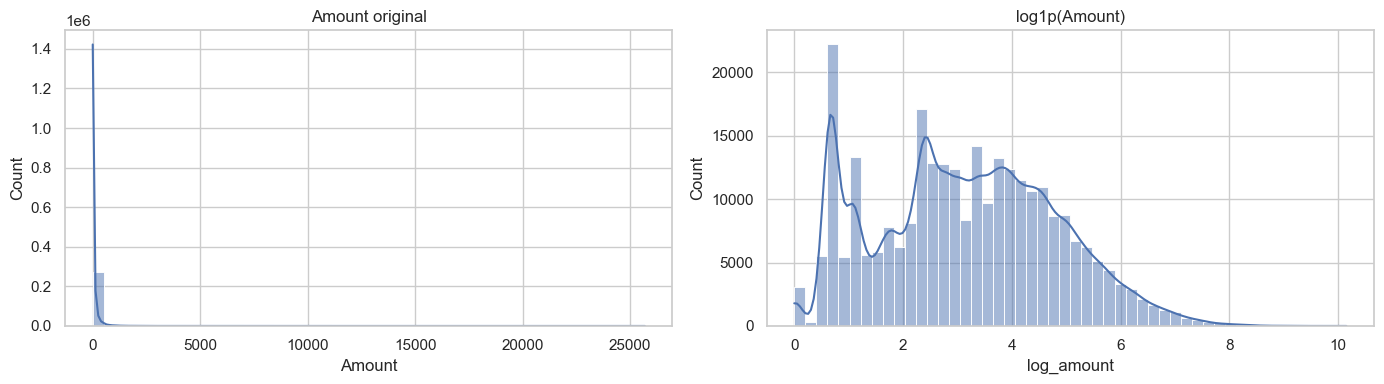

              Amount     log_amount
count  283726.000000  283726.000000
mean       88.472687       3.153760
std       250.399437       1.657080
min         0.000000       0.000000
25%         5.600000       1.887070
50%        22.000000       3.135494
75%        77.510000       4.363226
max     25691.160000      10.153941


In [4]:
df['log_amount'] = np.log1p(df['Amount'])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Amount'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Amount original')
sns.histplot(df['log_amount'], bins=50, ax=axes[1], kde=True)
axes[1].set_title('log1p(Amount)')
plt.tight_layout()
plt.show()
print(df[['Amount', 'log_amount']].describe())

**Interpretación:** `log_amount` distribuye mejor los montos bajos (la gran mayoría) y reduce la influencia de montos extremos.

## Sección 3 — Interacciones con PCA

Las V1..V28 son componentes PCA. Se resumen en `V_sum` y `V_mean` para capturar el 'nivel global' de anomalía en el espacio de componentes.

V_sum    -0.299493
V_mean   -0.299493
Class     1.000000
Name: Class, dtype: float64


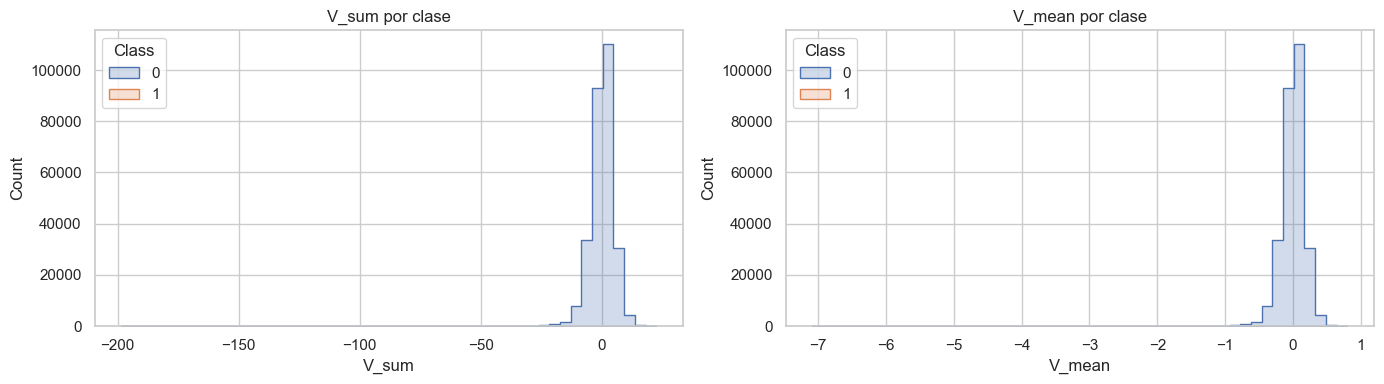

In [5]:
v_cols = [f'V{i}' for i in range(1, 29)]
df['V_sum'] = df[v_cols].sum(axis=1)
df['V_mean'] = df[v_cols].mean(axis=1)

corr = df[['V_sum', 'V_mean', 'Class']].corr()['Class']
print(corr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x='V_sum', hue='Class', bins=50, element='step', ax=axes[0])
axes[0].set_title('V_sum por clase')
sns.histplot(data=df, x='V_mean', hue='Class', bins=50, element='step', ax=axes[1])
axes[1].set_title('V_mean por clase')
plt.tight_layout()
plt.show()

## Sección 4 — Selección de features

Se evalúa la redundancia entre las features creadas y se elimina lo redundante.

**Interpretación:** `V_sum` y `V_mean` muestran cierta separación entre clases, pero son linealmente equivalentes (V_mean = V_sum / 28), por lo que `V_mean` se elimina como feature redundante.

## Sección 4 — Selección de features

Se elimina `V_mean` por redundancia lineal con `V_sum`. Se conservan todas las V originales, Time, Amount, Class y las nuevas features (hour, log_amount, V_sum). No se eliminan columnas de señal: el EDA mostró que las V más correlacionadas (V17, V14, V12, V10) son útiles.

In [6]:
df = df.drop(columns=['V_mean'])
print('Columnas finales:', list(df.columns))
print('Shape:', df.shape)
print('\nNueva feature creadas:', ['hour', 'log_amount', 'V_sum'])
print('Feature eliminada:', ['V_mean'], '(redundante: V_sum/28)')

Columnas finales: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'hour', 'log_amount', 'V_sum']
Shape: (283726, 34)

Nueva feature creadas: ['hour', 'log_amount', 'V_sum']
Feature eliminada: ['V_mean'] (redundante: V_sum/28)


## Conclusiones finales y próximos pasos

- Features creadas: `hour` (temporal), `log_amount` (monto robusto), `V_sum` (interacción PCA).
- `V_mean` eliminada por redundancia con `V_sum`.
- El CSV final conserva las mismas filas que el input (283,726) y la columna `Class` intacta.
- Próximo paso: modelado (notebook 03) usando estas features, sin escalar aquí y sin SMOTE.

In [7]:
df.to_csv('data/processed/creditcard_features.csv', index=False)
print('Guardado:', df.shape)

Guardado: (283726, 34)
